__Wer ist der Kunde?__<br />
Zachary Brooks ist ein Verkäufer, welcher in historische Häuser in besten Vierteln investiert um hohe Gewinne zu erzielen. Er möchte die beste Zeit zum Verkauf innerhalb eines Jahres wissen und ob es sinnvoll ist, diese vorher zu renovieren

Resultierende Kundenwünsche:
* historische Häuser
* beste Viertel
* hohe Gewinne
* bestes Timing
* innerhalb eines Jahres
* sollte renovieren?

Was sind historische Häuser?<br />
Wie definiert sich "beste Viertel"?<br />
Lohnt sich eine Renovierung?<br />
Was ist das beste Timing zum Verkauf?<br />
Wie verhält sich das innerhalb eines Jahres?


|Column|Description|
|---|---|
|id|A notation for a house
|date|Date house was sold
|price|Price is prediction target
|bedrooms|Number of bedrooms
|bathrooms|Number of bathrooms
|sqft_living|Square footage of the home
|sqft_lot|Square footage of the lot
|floors|Total floors (levels) in house
|waterfront|House which has a view to a waterfront
|view|Has been viewed
|condition|How good the condition is overall
|grade| 	overall grade given to the housing unit, based on King County grading system
|sqft_above| 	Square footage of house apart from basement
|sqft_basement| 	Square footage of the basement
|yr_built| 	Built Year
|yr_renovated| 	Year when house was renovated
|zipcode| 	Zip code
|lat| 	Latitude coordinate
|long| 	Longitude coordinate
|sqft_living15| 	Living room area in 2015(implies-- some renovations) This might or might not have affected the lotsize area
|sqft_lot15| 	LotSize area in 2015(implies-- some renovations)

---
## Datenaufbereitung ##

In [2]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns


#from matplotlib.ticker import PercentFormatter
#plt.rcParams.update({ "figure.figsize" : (8, 5),"axes.facecolor" : "white", "axes.edgecolor":  "black"})
#plt.rcParams["figure.facecolor"]= "w"
#pd.plotting.register_matplotlib_converters()
#pd.set_option('display.float_format', lambda x: '%.3f' % x)
#plt.show()

In [ ]:
# Read the dataset "king_county_house_details.csv" with 'date' column parsed as datetime
df_house_details = pd.read_csv('data/king_county_house_details.csv', parse_dates=['date'])

In [4]:
df_house_details.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21597 non-null  int64         
 1   bedrooms       21597 non-null  float64       
 2   bathrooms      21597 non-null  float64       
 3   sqft_living    21597 non-null  float64       
 4   sqft_lot       21597 non-null  float64       
 5   floors         21597 non-null  float64       
 6   waterfront     19206 non-null  float64       
 7   view           21534 non-null  float64       
 8   condition      21597 non-null  int64         
 9   grade          21597 non-null  int64         
 10  sqft_above     21597 non-null  float64       
 11  sqft_basement  21145 non-null  float64       
 12  yr_built       21597 non-null  int64         
 13  yr_renovated   17749 non-null  float64       
 14  zipcode        21597 non-null  int64         
 15  lat            2159

Erkenntnis:
* Es gibt 23 Spalten
* Alle Spalten haben non-null 

In [5]:
df_house_details.head(10)

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_id,id.1
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0,7129300520,1
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0,6414100192,2
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0,5631500400,3
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0,2487200875,4
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0,1954400510,5
5,7237550310,4.0,4.50,5420.0,101930.0,1.0,0.0,0.0,3,11,...,0.0,98053,47.6561,-122.005,4760.0,101930.0,2014-05-12,1230000.0,7237550310,6
6,1321400060,3.0,2.25,1715.0,6819.0,2.0,0.0,0.0,3,7,...,0.0,98003,47.3097,-122.327,2238.0,6819.0,2014-06-27,257500.0,1321400060,7
7,2008000270,3.0,1.50,1060.0,9711.0,1.0,0.0,NaN,3,7,...,0.0,98198,47.4095,-122.315,1650.0,9711.0,2015-01-15,291850.0,2008000270,8
8,2414600126,3.0,1.00,1780.0,7470.0,1.0,0.0,0.0,3,7,...,0.0,98146,47.5123,-122.337,1780.0,8113.0,2015-04-15,229500.0,2414600126,9
9,3793500160,3.0,2.50,1890.0,6560.0,2.0,0.0,0.0,3,7,...,0.0,98038,47.3684,-122.031,2390.0,7570.0,2015-03-12,323000.0,3793500160,10


Erkenntnisse:
* Werte mit 3 Nachkommastellen können auf 2 Nachkommestellen gerundet werden
* id.1 scheint die id+1 zu sein, also ab 1 angefangen zu zählen
* Es gibt NaN-Werte
* Es gibt die house_id und id, die sich auf dem ersten Blick zu ähneln scheinen

In [6]:
df_house_details.duplicated().value_counts()

False    21597
Name: count, dtype: int64

Erkenntnisse:
* Es gibt keine Duplikate in der Datenbank

In [7]:
df_house_details.dtypes

id                        int64
bedrooms                float64
bathrooms               float64
sqft_living             float64
sqft_lot                float64
floors                  float64
waterfront              float64
view                    float64
condition                 int64
grade                     int64
sqft_above              float64
sqft_basement           float64
yr_built                  int64
yr_renovated            float64
zipcode                   int64
lat                     float64
long                    float64
sqft_living15           float64
sqft_lot15              float64
date             datetime64[ns]
price                   float64
house_id                  int64
id.1                      int64
dtype: object

In [8]:
df_house_details

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_id,id.1
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0,7129300520,1
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0,6414100192,2
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0,5631500400,3
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0,2487200875,4
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0,1954400510,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21592,263000018,3.0,2.50,1530.0,1131.0,3.0,0.0,0.0,3,8,...,0.0,98103,47.6993,-122.346,1530.0,1509.0,2014-05-21,360000.0,263000018,21593
21593,6600060120,4.0,2.50,2310.0,5813.0,2.0,0.0,0.0,3,8,...,0.0,98146,47.5107,-122.362,1830.0,7200.0,2015-02-23,400000.0,6600060120,21594
21594,1523300141,2.0,0.75,1020.0,1350.0,2.0,0.0,0.0,3,7,...,0.0,98144,47.5944,-122.299,1020.0,2007.0,2014-06-23,402101.0,1523300141,21595
21595,291310100,3.0,2.50,1600.0,2388.0,2.0,NaN,0.0,3,8,...,0.0,98027,47.5345,-122.069,1410.0,1287.0,2015-01-16,400000.0,291310100,21596


Bevor tiefere Änderungen im Grunddatenbestand innerhalb des DataFrames gemacht werden, speichere ich sicherheitshalber<br />den Inhalt von DataFrame in einem Backup um eventuelle Rücksetzungen auf einem Stand zu ermöglichen.

In [9]:
# Backup original dataframe before data type conversions / if needed to reset the dataframe we are working with
df_backup_house_details = df_house_details.copy();

In [10]:
# if needed to reset
df_house_details = df_backup_house_details.copy();

In [11]:
# Check for decimal places in bedrooms and bathrooms
print(f"Schlafräume Nullkommastellen > 0: {(df_house_details['bedrooms'] % 1 != 0).sum()}")
print(f"Badezimmer Nullkommastellen > 0: {(df_house_details['bathrooms'] % 1 != 0).sum()}")

Schlafräume Nullkommastellen > 0: 0
Badezimmer Nullkommastellen > 0: 14898


In [12]:
# Convert data types of bedroom to int and bathrooms, floors, view, price to float with 2 decimal places
df_house_details['bedrooms'] = df_house_details['bedrooms'].round(0).astype(int)
#df_house_details[['bathrooms', 'floors', 'view', 'price']] = df_house_details[['bathrooms', 'floors', 'view', 'price']].round(2).astype(float)

#print(df_house_details[['bedrooms', 'bathrooms']].dtypes)
#print(df_house_details[['bedrooms', 'bathrooms']].head())

#print(df_house_details['date'].unique())
#print(df_house_details['bedrooms'].dtype)

df_house_details

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_id,id.1
0,7129300520,3,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0,7129300520,1
1,6414100192,3,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0,6414100192,2
2,5631500400,2,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0,5631500400,3
3,2487200875,4,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0,2487200875,4
4,1954400510,3,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0,1954400510,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21592,263000018,3,2.50,1530.0,1131.0,3.0,0.0,0.0,3,8,...,0.0,98103,47.6993,-122.346,1530.0,1509.0,2014-05-21,360000.0,263000018,21593
21593,6600060120,4,2.50,2310.0,5813.0,2.0,0.0,0.0,3,8,...,0.0,98146,47.5107,-122.362,1830.0,7200.0,2015-02-23,400000.0,6600060120,21594
21594,1523300141,2,0.75,1020.0,1350.0,2.0,0.0,0.0,3,7,...,0.0,98144,47.5944,-122.299,1020.0,2007.0,2014-06-23,402101.0,1523300141,21595
21595,291310100,3,2.50,1600.0,2388.0,2.0,NaN,0.0,3,8,...,0.0,98027,47.5345,-122.069,1410.0,1287.0,2015-01-16,400000.0,291310100,21596


Kundenwünsche:
* historische Häuser (yr_built)
* beste Viertel (zipcode, waterfront, grade, condition)
* hohe Gewinne (Ziel)
* bestes Timing (gilt es herauszufinden, view )
* innerhalb eines Jahres (2014,2015)
* sollte renovieren? (yr_renovated)

___*Wie verhalten sich die Preise nach Renovierung im Verhältnis zu denen ohne Reservierung?*___

In [40]:
#df_house_details['yr_renovated'] = df_house_details['yr_renovated'].round(0).astype(int)

#mask = df_house_details['yr_renovated'].notna()
df_house_details.loc[df_house_details['yr_renovated'].notna(), 'yr_renovated'] = df_house_details.loc[df_house_details['yr_renovated'].notna(), 'yr_renovated'].astype(int)

df_house_details

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3,1.00,109.63,524.90,1.0,NaN,0.0,3,7,...,0.00,1955,0.0,98178,47.5112,-122.257,124.49,524.90,2014-10-13,221900.0
1,6414100192,3,2.25,238.76,672.80,2.0,0.0,0.0,3,7,...,37.16,1951,19910.0,98125,47.7210,-122.319,157.01,709.69,2014-12-09,538000.0
2,5631500400,2,1.00,71.54,929.03,1.0,0.0,0.0,3,6,...,0.00,1933,NaN,98028,47.7379,-122.233,252.70,748.98,2015-02-25,180000.0
3,2487200875,4,3.00,182.09,464.52,1.0,0.0,0.0,5,7,...,84.54,1965,0.0,98136,47.5208,-122.393,126.35,464.52,2014-12-09,604000.0
4,1954400510,3,2.00,156.08,750.66,1.0,0.0,0.0,3,8,...,0.00,1987,0.0,98074,47.6168,-122.045,167.23,697.05,2015-02-18,510000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21592,263000018,3,2.50,142.14,105.07,3.0,0.0,0.0,3,8,...,0.00,2009,0.0,98103,47.6993,-122.346,142.14,140.19,2014-05-21,360000.0
21593,6600060120,4,2.50,214.61,540.05,2.0,0.0,0.0,3,8,...,0.00,2014,0.0,98146,47.5107,-122.362,170.01,668.90,2015-02-23,400000.0
21594,1523300141,2,0.75,94.76,125.42,2.0,0.0,0.0,3,7,...,0.00,2009,0.0,98144,47.5944,-122.299,94.76,186.46,2014-06-23,402101.0
21595,291310100,3,2.50,148.64,221.85,2.0,NaN,0.0,3,8,...,0.00,2004,0.0,98027,47.5345,-122.069,130.99,119.57,2015-01-16,400000.0


In [13]:
# Check if 'id' and 'house_id' are identical
if 'house_id' in df_house_details.columns:
    print((df_house_details['id'] == df_house_details['house_id']).all())

    # If they are identical, drop 'house_id'
    if (df_house_details['id'] == df_house_details['house_id']).all():
        df_house_details.drop(columns=['house_id'], inplace=True)

if 'id.1' in df_house_details.columns:
    df_house_details.drop(columns=['id.1'], inplace=True)

df_house_details

True


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0
1,6414100192,3,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0
2,5631500400,2,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0
3,2487200875,4,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0
4,1954400510,3,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21592,263000018,3,2.50,1530.0,1131.0,3.0,0.0,0.0,3,8,...,0.0,2009,0.0,98103,47.6993,-122.346,1530.0,1509.0,2014-05-21,360000.0
21593,6600060120,4,2.50,2310.0,5813.0,2.0,0.0,0.0,3,8,...,0.0,2014,0.0,98146,47.5107,-122.362,1830.0,7200.0,2015-02-23,400000.0
21594,1523300141,2,0.75,1020.0,1350.0,2.0,0.0,0.0,3,7,...,0.0,2009,0.0,98144,47.5944,-122.299,1020.0,2007.0,2014-06-23,402101.0
21595,291310100,3,2.50,1600.0,2388.0,2.0,NaN,0.0,3,8,...,0.0,2004,0.0,98027,47.5345,-122.069,1410.0,1287.0,2015-01-16,400000.0


In [14]:
# Calculate sqft to m² (1 sqft = 0.092903 m²)
df_house_details['sqft_living'] = (df_house_details['sqft_living'] * 0.092903).round(2)
df_house_details['sqft_lot'] = (df_house_details['sqft_lot'] * 0.092903).round(2)
df_house_details['sqft_above'] = (df_house_details['sqft_above'] * 0.092903).round(2)
df_house_details['sqft_basement'] = (df_house_details['sqft_basement'] * 0.092903).round(2)
df_house_details['sqft_living15'] = (df_house_details['sqft_living15'] * 0.092903).round(2)
df_house_details['sqft_lot15'] = (df_house_details['sqft_lot15'] * 0.092903).round(2)

df_house_details

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3,1.00,109.63,524.90,1.0,NaN,0.0,3,7,...,0.00,1955,0.0,98178,47.5112,-122.257,124.49,524.90,2014-10-13,221900.0
1,6414100192,3,2.25,238.76,672.80,2.0,0.0,0.0,3,7,...,37.16,1951,19910.0,98125,47.7210,-122.319,157.01,709.69,2014-12-09,538000.0
2,5631500400,2,1.00,71.54,929.03,1.0,0.0,0.0,3,6,...,0.00,1933,NaN,98028,47.7379,-122.233,252.70,748.98,2015-02-25,180000.0
3,2487200875,4,3.00,182.09,464.52,1.0,0.0,0.0,5,7,...,84.54,1965,0.0,98136,47.5208,-122.393,126.35,464.52,2014-12-09,604000.0
4,1954400510,3,2.00,156.08,750.66,1.0,0.0,0.0,3,8,...,0.00,1987,0.0,98074,47.6168,-122.045,167.23,697.05,2015-02-18,510000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21592,263000018,3,2.50,142.14,105.07,3.0,0.0,0.0,3,8,...,0.00,2009,0.0,98103,47.6993,-122.346,142.14,140.19,2014-05-21,360000.0
21593,6600060120,4,2.50,214.61,540.05,2.0,0.0,0.0,3,8,...,0.00,2014,0.0,98146,47.5107,-122.362,170.01,668.90,2015-02-23,400000.0
21594,1523300141,2,0.75,94.76,125.42,2.0,0.0,0.0,3,7,...,0.00,2009,0.0,98144,47.5944,-122.299,94.76,186.46,2014-06-23,402101.0
21595,291310100,3,2.50,148.64,221.85,2.0,NaN,0.0,3,8,...,0.00,2004,0.0,98027,47.5345,-122.069,130.99,119.57,2015-01-16,400000.0


In [25]:
df_house_details['date'].nunique

<bound method IndexOpsMixin.nunique of 0       2014-10-13
1       2014-12-09
2       2015-02-25
3       2014-12-09
4       2015-02-18
           ...    
21592   2014-05-21
21593   2015-02-23
21594   2014-06-23
21595   2015-01-16
21596   2014-10-15
Name: date, Length: 21597, dtype: datetime64[ns]>

Kundenwünsche:
* historische Häuser (yr_built)
* beste Viertel (zipcode, waterfront, grade, condition)
* hohe Gewinne (Ziel)
* bestes Timing (gilt es herauszufinden, view )
* innerhalb eines Jahres (2014,2015)
* sollte renovieren? (yr_renovated)

In [15]:
df_house_details.describe()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
count,2.159700e+04,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,19206.000000,21534.000000,21597.000000,21597.000000,...,21145.000000,21597.000000,17749.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597,2.159700e+04
mean,4.580474e+09,3.373200,2.115826,193.268173,1402.780390,1.494096,0.007602,0.233863,3.409825,7.657915,...,27.114360,1970.999676,836.650516,98077.951845,47.560093,-122.213983,184.562988,1185.282788,2014-10-29 04:20:38.171968512,5.402966e+05
min,1.000102e+06,1.000000,0.500000,34.370000,48.310000,1.000000,0.000000,0.000000,1.000000,3.000000,...,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,37.070000,60.480000,2014-05-02 00:00:00,7.800000e+04
25%,2.123049e+09,3.000000,1.750000,132.850000,468.230000,1.000000,0.000000,0.000000,3.000000,7.000000,...,0.000000,1951.000000,0.000000,98033.000000,47.471100,-122.328000,138.430000,473.810000,2014-07-22 00:00:00,3.220000e+05
50%,3.904930e+09,3.000000,2.250000,177.440000,707.740000,1.500000,0.000000,0.000000,3.000000,7.000000,...,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.231000,170.940000,707.920000,2014-10-16 00:00:00,4.500000e+05
75%,7.308900e+09,4.000000,2.500000,236.900000,992.670000,2.000000,0.000000,0.000000,4.000000,8.000000,...,52.030000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,219.250000,936.740000,2015-02-17 00:00:00,6.450000e+05
max,9.900000e+09,33.000000,8.000000,1257.910000,153416.210000,3.500000,1.000000,4.000000,5.000000,13.000000,...,447.790000,2015.000000,20150.000000,98199.000000,47.777600,-121.315000,576.930000,80937.090000,2015-05-27 00:00:00,7.700000e+06
std,2.876736e+09,0.926299,0.768984,85.294829,3847.358171,0.539683,0.086858,0.765686,0.650546,1.173200,...,41.108625,29.375234,4000.110554,53.513072,0.138552,0.140724,63.659992,2533.877451,NaN,3.673681e+05


Kundenwünsche:
* historische Häuser (yr_built)
* beste Viertel (zipcode, waterfront, grade, condition)
* hohe Gewinne (Ziel)
* bestes Timing (gilt es herauszufinden, view )
* innerhalb eines Jahres (2014,2015)
* sollte renovieren? (yr_renovated)

Definition:<br/>
___*Eine Immobilie gilt nur dann als historisch, wenn diese mindestens 50 Jahre alt ist.*___

In [24]:
# Identify houses that are 50 years or older from 2015
df_house_details[
    (
        ((datetime.now().year - df_house_details['yr_built']) >= 50) & 
        (df_house_details['date'].dt.year == 2015)  
        #(df_house_details['grade'] > 8)
    )
]
#[['id','date','waterfront','view','condition','grade','zipcode','yr_built','yr_renovated']]

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
2,5631500400,2,1.0,71.54,929.03,1.0,0.0,0.0,3,6,...,0.00,1933,NaN,98028,47.7379,-122.233,252.70,748.98,2015-02-25,180000.0
7,2008000270,3,1.5,98.48,902.18,1.0,0.0,NaN,3,7,...,0.00,1963,0.0,98198,47.4095,-122.315,153.29,902.18,2015-01-15,291850.0
8,2414600126,3,1.0,165.37,693.99,1.0,0.0,0.0,3,7,...,67.82,1960,0.0,98146,47.5123,-122.337,165.37,753.72,2015-04-15,229500.0
10,1736800520,3,2.5,330.73,910.08,1.0,NaN,0.0,3,8,...,157.94,1965,0.0,98007,47.6007,-122.145,205.32,829.16,2015-04-03,662500.0
14,1175000570,5,2.0,168.15,450.58,1.5,0.0,0.0,3,7,...,0.00,1900,0.0,98107,47.6700,-122.394,126.35,450.58,2015-03-12,530000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21063,3449000010,3,1.0,105.91,780.39,1.0,0.0,0.0,4,7,...,0.00,1960,0.0,98059,47.5022,-122.144,130.06,836.13,2015-03-12,294570.0
21224,7174800094,1,1.5,95.69,550.26,1.0,NaN,0.0,3,8,...,0.00,1940,NaN,98105,47.6653,-122.305,246.19,464.52,2015-04-20,525000.0
21287,522059130,3,1.0,106.84,1690.83,1.0,0.0,0.0,5,7,...,0.00,1959,0.0,98058,47.4262,-122.187,159.24,1690.83,2015-04-29,465000.0
21316,9266700190,1,1.0,36.23,185.81,1.0,0.0,0.0,4,6,...,0.00,1920,0.0,98103,47.6938,-122.347,124.49,473.81,2015-05-11,245000.0


Kundenwünsche:
* historische Häuser (yr_built)
* beste Viertel (zipcode, waterfront, grade, condition)
* hohe Gewinne (Ziel)
* bestes Timing (gilt es herauszufinden, view )
* innerhalb eines Jahres (2014,2015)
* sollte renovieren? (yr_renovated)

Definition:<br/>
___*Ein gutes Viertel besitzt Gewässer.*___

In [21]:
zipcode_list = df_house_details[(
    (df_house_details['waterfront'] > 0)
)]['zipcode']

zipcode_list.values

array([98070, 98166, 98074, 98070, 98074, 98070, 98166, 98034, 98178,
       98034, 98178, 98033, 98070, 98166, 98040, 98052, 98155, 98178,
       98074, 98070, 98040, 98040, 98008, 98006, 98075, 98008, 98155,
       98144, 98070, 98166, 98178, 98006, 98004, 98070, 98075, 98199,
       98056, 98146, 98023, 98116, 98075, 98040, 98075, 98070, 98008,
       98155, 98178, 98070, 98027, 98118, 98136, 98105, 98040, 98040,
       98052, 98040, 98040, 98006, 98040, 98023, 98075, 98118, 98070,
       98075, 98006, 98198, 98125, 98040, 98125, 98023, 98166, 98033,
       98034, 98166, 98136, 98136, 98178, 98105, 98034, 98115, 98198,
       98075, 98198, 98166, 98144, 98074, 98198, 98166, 98198, 98070,
       98027, 98033, 98008, 98166, 98070, 98136, 98177, 98118, 98040,
       98070, 98039, 98198, 98136, 98178, 98074, 98075, 98155, 98155,
       98166, 98178, 98125, 98028, 98166, 98146, 98178, 98146, 98070,
       98070, 98070, 98146, 98166, 98198, 98125, 98146, 98034, 98070,
       98008, 98070,

In [ ]:
# Identify houses that are 50 years or older from 2015 and check if they are in the best neighborhoods
df_house_details[
    (
        ((datetime.now().year - df_house_details['yr_built']) >= 50) & 
        (df_house_details['date'].dt.year == 2015) &
        (df_house_details['zipcode'].isin(zipcode_list.values))
    )
]

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
2,5631500400,2,1.00,71.54,929.03,1.0,0.0,0.0,3,6,...,0.00,1933,NaN,98028,47.7379,-122.233,252.70,748.98,2015-02-25,180000.0
7,2008000270,3,1.50,98.48,902.18,1.0,0.0,NaN,3,7,...,0.00,1963,0.0,98198,47.4095,-122.315,153.29,902.18,2015-01-15,291850.0
8,2414600126,3,1.00,165.37,693.99,1.0,0.0,0.0,3,7,...,67.82,1960,0.0,98146,47.5123,-122.337,165.37,753.72,2015-04-15,229500.0
46,8945200830,3,1.00,91.97,792.28,1.0,0.0,0.0,3,6,...,0.00,1966,0.0,98023,47.3066,-122.371,114.08,821.26,2015-03-25,210490.0
48,9215400105,3,1.75,116.13,553.98,1.0,0.0,0.0,4,7,...,0.00,1953,0.0,98115,47.6796,-122.301,90.12,473.81,2015-04-28,450000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19606,7351200295,3,1.75,163.51,630.63,2.0,1.0,4.0,3,7,...,0.00,1940,NaN,98125,47.7336,-122.284,151.43,704.95,2015-01-14,1150000.0
20431,3319500628,3,1.50,93.83,143.63,2.0,NaN,0.0,3,8,...,0.00,1971,20140.0,98144,47.5998,-122.311,93.83,140.93,2015-02-12,356999.0
20731,2926049582,2,1.50,100.71,318.38,2.0,0.0,0.0,3,7,...,0.00,1976,0.0,98125,47.7117,-122.326,100.71,580.64,2015-04-12,265000.0
21224,7174800094,1,1.50,95.69,550.26,1.0,NaN,0.0,3,8,...,0.00,1940,NaN,98105,47.6653,-122.305,246.19,464.52,2015-04-20,525000.0


In [ ]:
#####
# Identify houses that are 50 years or older from 2015 and check if they are in the best neighborhoods
df_house_details[
    (
        ((datetime.now().year - df_house_details['yr_built']) >= 50) & 
        (df_house_details['date'].dt.year == 2015) &
        (df_house_details['zipcode'].isin(zipcode_list.values))
    )
]

df_house_details['yr_renovated']

0            0.0
1        19910.0
2            NaN
3            0.0
4            0.0
          ...   
21592        0.0
21593        0.0
21594        0.0
21595        0.0
21596        0.0
Name: yr_renovated, Length: 21597, dtype: float64

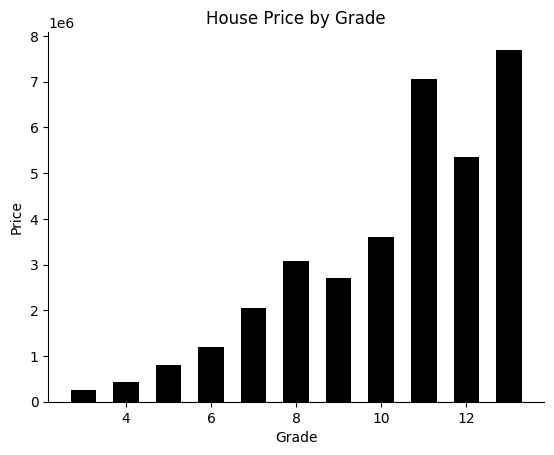

In [179]:
fig, ax = plt.subplots()

ax.set_title('House Price by Grade')

ax.set_xlabel('Grade')
ax.set_ylabel('Price')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#ax.scatter(df_house_details['grade'], df_house_details['price'], alpha=0.5)
bars = ax.bar(df_house_details['grade'], df_house_details['price'], color='black', width=0.6)

plt.show()

#df_house_details['grade'].describe()